In [1]:
"""KNN training and evaluation helpers based on train_knn.py."""

import csv
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt


FEATURE_NAMES = (
    "ax1", "ay1", "az1", "gx1", "gy1", "gz1",
    "ax2", "ay2", "az2", "gx2", "gy2", "gz2",
)
DATA_FILES = [Path("data/train.csv")]
DEFAULT_PROTOTYPES_PER_LABEL = 64
K_NEIGHBORS = 5


def load_rows(paths):
    rows = []
    for path in paths:
        with path.open(newline="", encoding="utf-8") as csv_file:
            for row in csv.DictReader(csv_file):
                label = row.get("label", "").strip()
                if not label or label.lower() == "label":
                    continue
                try:
                    features = [float(row[name]) for name in FEATURE_NAMES]
                except (KeyError, TypeError, ValueError):
                    continue
                rows.append((label, features))
    if not rows:
        raise ValueError("No valid labeled rows were found in the input CSV files.")
    return rows


def choose_prototypes(rows, per_label):
    grouped = {}
    for label, features in rows:
        grouped.setdefault(label, []).append(features)

    selected = []
    for label in sorted(grouped):
        label_rows = grouped[label]
        count = min(per_label, len(label_rows))
        indexes = [
            round(index * (len(label_rows) - 1) / (count - 1))
            for index in range(count)
        ] if count > 1 else [0]
        selected.extend((label, label_rows[index]) for index in indexes)
    return selected


def calculate_scaling(rows):
    means = [sum(features[index] for _, features in rows) / len(rows) for index in range(len(FEATURE_NAMES))]
    scales = []
    for index, mean in enumerate(means):
        variance = sum((features[index] - mean) ** 2 for _, features in rows) / len(rows)
        scales.append(math.sqrt(variance) or 1.0)
    return means, scales


def normalize(features, means, scales):
    return [(value - mean) / scale for value, mean, scale in zip(features, means, scales)]


def predict(features, training, means, scales, k=K_NEIGHBORS):
    normalized = normalize(features, means, scales)
    distances = [
        (
            sum(
                (value - reference) ** 2
                for value, reference in zip(normalized, normalize(row, means, scales))
            ),
            label,
        )
        for label, row in training
    ]
    nearest = sorted(distances, key=lambda item: item[0])[:min(k, len(distances))]
    return Counter(label for _, label in nearest).most_common(1)[0][0]


def stratified_split(rows, validation_fraction=0.2, seed=42):
    random_generator = random.Random(seed)
    groups = {}
    for label, features in rows:
        groups.setdefault(label, []).append((label, features))

    training_rows = []
    validation_rows = []
    for label_rows in groups.values():
        random_generator.shuffle(label_rows)
        split_index = max(1, int(len(label_rows) * (1 - validation_fraction)))
        training_rows.extend(label_rows[:split_index])
        validation_rows.extend(label_rows[split_index:])
    return training_rows, validation_rows


def evaluate(validation_rows, training, means, scales, k):
    normalized_training = [
        (label, normalize(features, means, scales))
        for label, features in training
    ]
    actual = [label for label, _ in validation_rows]
    predictions = []
    for _, features in validation_rows:
        normalized = normalize(features, means, scales)
        distances = [
            (sum((value - reference) ** 2 for value, reference in zip(normalized, prototype)), label)
            for label, prototype in normalized_training
        ]
        nearest = sorted(distances, key=lambda item: item[0])[:min(k, len(distances))]
        predictions.append(Counter(label for _, label in nearest).most_common(1)[0][0])
    accuracy = sum(expected == predicted for expected, predicted in zip(actual, predictions)) / len(actual)
    return accuracy, actual, predictions

In [2]:
# Use only the existing train.csv file. It is never modified by this notebook.
PROJECT_ROOT = Path(r"E:\BE computer engineering\6th sem\minor project\Minor-project")
DATA_FILES = [PROJECT_ROOT / "data" / "train.csv"]
rows = load_rows(DATA_FILES)
print(f"Loaded {len(rows)} rows")
print("Labels:", dict(sorted(Counter(label for label, _ in rows).items())))

Loaded 222203 rows
Labels: {'bicep_bad': 48800, 'bicep_good': 30450, 'bicep_idle': 30950, 'pushup_bad': 10399, 'pushup_good': 33754, 'pushup_idle': 27100, 'squat_bad': 15850, 'squat_good': 14400, 'squat_idle': 10500}


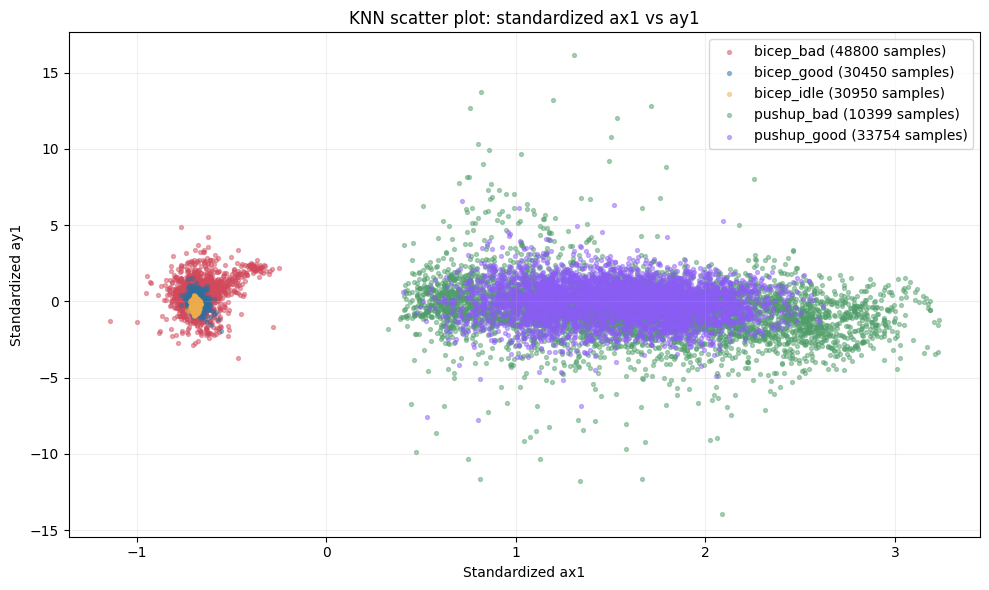

In [3]:
import csv
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt


points_by_label = defaultdict(list)
for dataset_path in DATA_FILES:
    with dataset_path.open(newline="", encoding="utf-8") as csv_file:
        for row in csv.DictReader(csv_file):
            label = row.get("label", "").strip()
            if label and label != "label":
                points_by_label[label].append((float(row["ax1"]), float(row["ay1"])))

all_points = [point for points in points_by_label.values() for point in points]
means = [sum(point[index] for point in all_points) / len(all_points) for index in range(2)]
scales = [
    math.sqrt(sum((point[index] - means[index]) ** 2 for point in all_points) / len(all_points)) or 1.0
    for index in range(2)
]

plt.figure(figsize=(10, 6))
colors = ["#d1495b", "#2f6f9f", "#edae49", "#4f9d69", "#8b5cf6"]
for color, label in zip(colors, sorted(points_by_label)):
    points = points_by_label[label]
    step = max(1, len(points) // 4000)
    normalized = [
        ((point[0] - means[0]) / scales[0], (point[1] - means[1]) / scales[1])
        for point in points[::step]
    ]
    plt.scatter(
        [point[0] for point in normalized],
        [point[1] for point in normalized],
        s=8,
        alpha=0.45,
        color=color,
        label=f"{label} ({len(points)} samples)",
    )

plt.title("KNN scatter plot: standardized ax1 vs ay1")
plt.xlabel("Standardized ax1")
plt.ylabel("Standardized ay1")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

Evaluating 2700 validation samples (300 per label maximum)
Best parameters: {'prototypes_per_label': 128, 'k': 1, 'accuracy': 0.8381481481481482}


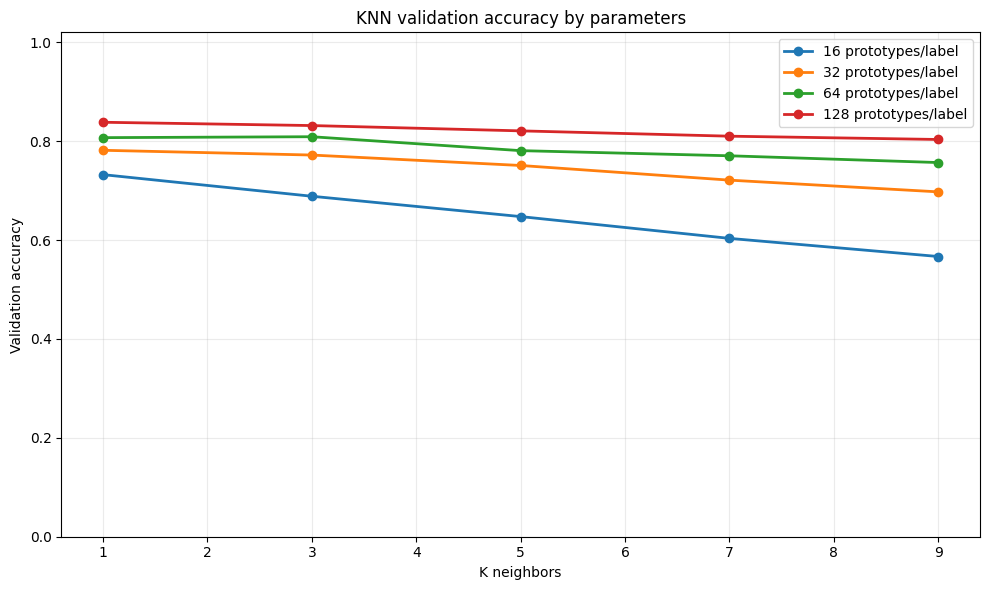

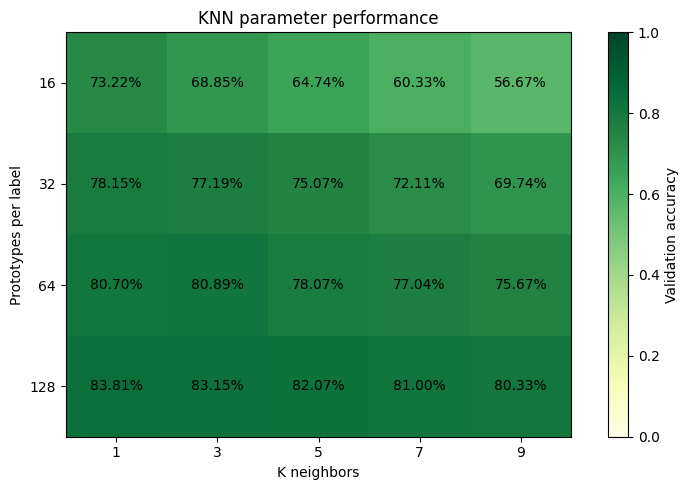

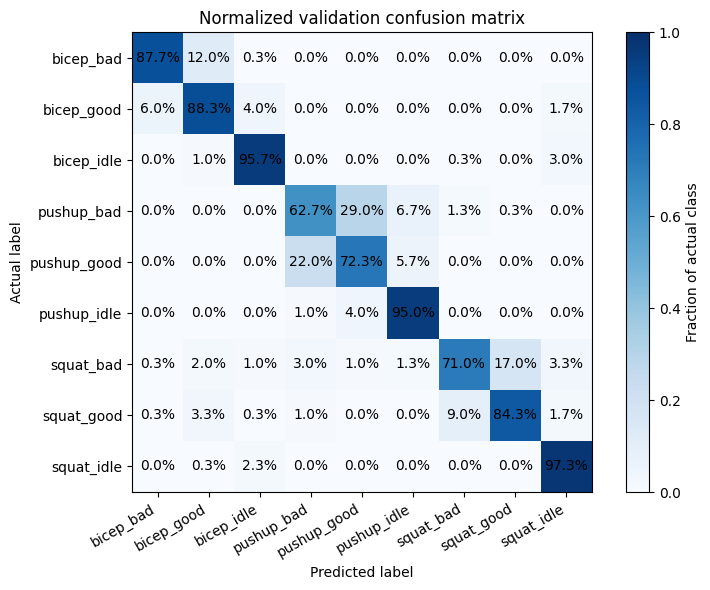

bicep_bad: precision=92.93%, recall=87.67%, F1=90.22%
bicep_good: precision=82.55%, recall=88.33%, F1=85.35%
bicep_idle: precision=92.28%, recall=95.67%, F1=93.94%
pushup_bad: precision=69.89%, recall=62.67%, F1=66.08%
pushup_good: precision=68.03%, recall=72.33%, F1=70.11%
pushup_idle: precision=87.42%, recall=95.00%, F1=91.05%
squat_bad: precision=86.94%, recall=71.00%, F1=78.17%
squat_good: precision=82.95%, recall=84.33%, F1=83.64%
squat_idle: precision=90.97%, recall=97.33%, F1=94.04%


In [4]:
# Evaluate KNN on a reproducible stratified validation sample using different k and prototype counts.
all_rows = load_rows(DATA_FILES)
training_rows, validation_rows = stratified_split(all_rows, validation_fraction=0.2, seed=42)

# Keep every label represented while making the parameter sweep practical.
EVALUATION_SAMPLES_PER_LABEL = 300
validation_groups = {}
for row in validation_rows:
    validation_groups.setdefault(row[0], []).append(row)
evaluation_rows = [
    row
    for label in sorted(validation_groups)
    for row in validation_groups[label][:EVALUATION_SAMPLES_PER_LABEL]
]
print(f"Evaluating {len(evaluation_rows)} validation samples ({EVALUATION_SAMPLES_PER_LABEL} per label maximum)")

k_values = [1, 3, 5, 7, 9]
prototype_values = [16, 32, 64, 128]
results = []

for prototype_count in prototype_values:
    prototype_rows = choose_prototypes(training_rows, prototype_count)
    means, scales = calculate_scaling(prototype_rows)
    for k in k_values:
        accuracy, actual, predictions = evaluate(
            evaluation_rows, prototype_rows, means, scales, k
        )
        results.append({
            "prototypes_per_label": prototype_count,
            "k": k,
            "accuracy": accuracy,
        })

best_result = max(results, key=lambda result: result["accuracy"])
print("Best parameters:", best_result)

# Graph 1: validation accuracy for every parameter combination.
plt.figure(figsize=(10, 6))
for prototype_count in prototype_values:
    values = [
        next(result["accuracy"] for result in results
             if result["prototypes_per_label"] == prototype_count and result["k"] == k)
        for k in k_values
    ]
    plt.plot(k_values, values, marker="o", linewidth=2, label=f"{prototype_count} prototypes/label")
plt.xlabel("K neighbors")
plt.ylabel("Validation accuracy")
plt.title("KNN validation accuracy by parameters")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Graph 2: heatmap of validation accuracy.
accuracy_matrix = [
    [next(result["accuracy"] for result in results
          if result["prototypes_per_label"] == prototype_count and result["k"] == k)
     for k in k_values]
    for prototype_count in prototype_values
]
plt.figure(figsize=(8, 5))
image = plt.imshow(accuracy_matrix, cmap="YlGn", vmin=0, vmax=1)
plt.colorbar(image, label="Validation accuracy")
plt.xticks(range(len(k_values)), k_values)
plt.yticks(range(len(prototype_values)), prototype_values)
plt.xlabel("K neighbors")
plt.ylabel("Prototypes per label")
plt.title("KNN parameter performance")
for row_index in range(len(prototype_values)):
    for column_index in range(len(k_values)):
        plt.text(column_index, row_index, f"{accuracy_matrix[row_index][column_index]:.2%}", ha="center", va="center")
plt.tight_layout()
plt.show()

# Graph 3: normalized confusion matrix for the best parameters.
best_training = choose_prototypes(training_rows, best_result["prototypes_per_label"])
best_means, best_scales = calculate_scaling(best_training)
_, actual, predictions = evaluate(
    evaluation_rows, best_training, best_means, best_scales, best_result["k"]
)
labels = sorted(set(actual) | set(predictions))
label_ids = {label: index for index, label in enumerate(labels)}
confusion = [[0 for _ in labels] for _ in labels]
for expected, predicted in zip(actual, predictions):
    confusion[label_ids[expected]][label_ids[predicted]] += 1

normalized_confusion = []
for row in confusion:
    total = sum(row)
    normalized_confusion.append([value / total if total else 0.0 for value in row])

plt.figure(figsize=(8, 6))
image = plt.imshow(normalized_confusion, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(image, label="Fraction of actual class")
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Normalized validation confusion matrix")
for row_index in range(len(labels)):
    for column_index in range(len(labels)):
        plt.text(column_index, row_index, f"{normalized_confusion[row_index][column_index]:.1%}", ha="center", va="center")
plt.tight_layout()
plt.show()

# Print per-class precision, recall, and F1 for the selected parameters.
for label in labels:
    true_positive = sum(expected == label and predicted == label for expected, predicted in zip(actual, predictions))
    false_positive = sum(expected != label and predicted == label for expected, predicted in zip(actual, predictions))
    false_negative = sum(expected == label and predicted != label for expected, predicted in zip(actual, predictions))
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    print(f"{label}: precision={precision:.2%}, recall={recall:.2%}, F1={f1:.2%}")

In [5]:
# Evaluate larger prototype counts for the real-time ESP32 target range.
realtime_prototype_values = [512, 1024]
realtime_results = []

for prototype_count in realtime_prototype_values:
    prototype_rows = choose_prototypes(training_rows, prototype_count)
    means, scales = calculate_scaling(prototype_rows)
    accuracy, actual, predictions = evaluate(
        evaluation_rows, prototype_rows, means, scales, K_NEIGHBORS
    )
    realtime_results.append({
        "prototypes_per_label": prototype_count,
        "k": K_NEIGHBORS,
        "accuracy": accuracy,
    })
    print(f"{prototype_count} prototypes/label, k={K_NEIGHBORS}: accuracy={accuracy:.2%}")

    labels = sorted(set(actual) | set(predictions))
    for label in labels:
        true_positive = sum(
            expected == label and predicted == label
            for expected, predicted in zip(actual, predictions)
        )
        false_positive = sum(
            expected != label and predicted == label
            for expected, predicted in zip(actual, predictions)
        )
        false_negative = sum(
            expected == label and predicted != label
            for expected, predicted in zip(actual, predictions)
        )
        precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
        recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        print(f"  {label}: precision={precision:.2%}, recall={recall:.2%}, F1={f1:.2%}")

best_realtime_result = max(realtime_results, key=lambda result: result["accuracy"])
print("Best real-time target:", best_realtime_result)

512 prototypes/label, k=5: accuracy=89.59%
  bicep_bad: precision=94.22%, recall=92.33%, F1=93.27%
  bicep_good: precision=92.54%, recall=91.00%, F1=91.76%
  bicep_idle: precision=93.89%, recall=97.33%, F1=95.58%
  pushup_bad: precision=82.42%, recall=75.00%, F1=78.53%
  pushup_good: precision=79.93%, recall=81.00%, F1=80.46%
  pushup_idle: precision=91.61%, recall=98.33%, F1=94.86%
  squat_bad: precision=88.81%, recall=82.00%, F1=85.27%
  squat_good: precision=85.62%, recall=91.33%, F1=88.39%
  squat_idle: precision=96.71%, recall=98.00%, F1=97.35%
1024 prototypes/label, k=5: accuracy=91.67%
  bicep_bad: precision=93.71%, recall=94.33%, F1=94.02%
  bicep_good: precision=95.12%, recall=91.00%, F1=93.02%
  bicep_idle: precision=95.50%, recall=99.00%, F1=97.22%
  pushup_bad: precision=85.56%, recall=79.00%, F1=82.15%
  pushup_good: precision=81.47%, recall=85.00%, F1=83.20%
  pushup_idle: precision=93.99%, recall=99.00%, F1=96.43%
  squat_bad: precision=94.72%, recall=83.67%, F1=88.85%
 